# Lab 2 — Imputação de Valores Ausentes

**Disciplina:** Tópicos em Eng. Software - Ciência de Dados  
**Professor:** Prof. Eduardo Pena  

Este notebook implementa o protocolo completo de avaliação de técnicas de imputação de valores ausentes sob diferentes mecanismos (MCAR, MAR, MNAR) e percentuais de missingness.

### Estrutura:
1. Bibliotecas e configuração
2. Metadados e funções de carga dos datasets
3. Implementação da injeção controlada de valores ausentes (compatível com Jenga)
4. Imputadores (sklearn + método externo)
5. Pipeline experimental
6. Execução e resultados
7. Visualizações


In [1]:
# ============================================================
# CÉLULA 1 — Instalação de dependências
# ============================================================
# Execute esta célula apenas uma vez para instalar os pacotes necessários
import subprocess, sys

pkgs = ["lightgbm", "scikit-learn", "pandas", "numpy", "tqdm", "joblib", "matplotlib", "seaborn"]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

# Tenta instalar jenga; se falhar, usamos implementação própria compatível
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "git+https://github.com/schelterlabs/jenga.git", "-q"],
    capture_output=True, text=True
)
JENGA_AVAILABLE = result.returncode == 0
print("Jenga instalado via pip:", JENGA_AVAILABLE)
print("Se False, será usada implementação compatível local.")

Jenga instalado via pip: False
Se False, será usada implementação compatível local.


In [2]:
# ============================================================
# CÉLULA 2 — Bibliotecas
# ============================================================
from __future__ import annotations

import json
import zipfile
import warnings
import time
from pathlib import Path
from urllib.request import urlretrieve
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)

print("Todas as bibliotecas carregadas com sucesso!")
print(f"sklearn: {__import__('sklearn').__version__}")
print(f"lightgbm: {lgb.__version__}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")

c:\Users\kslima\mestrado\cienciaDados\atv2\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Todas as bibliotecas carregadas com sucesso!
sklearn: 1.6.1
lightgbm: 4.6.0
numpy: 2.0.2
pandas: 2.3.3


In [3]:
# ============================================================
# CÉLULA 3 — Implementação de Injeção de Valores Ausentes
# Compatível com a interface do Jenga (MCAR, MAR, MNAR)
# Se o Jenga estiver disponível, usa o Jenga; caso contrário,
# usa implementação própria com a mesma semântica.
# ============================================================

try:
    from jenga.corruptions.generic import MissingValues as JengaMV
    JENGA_AVAILABLE = True
    print("Jenga carregado com sucesso!")
except ImportError:
    JENGA_AVAILABLE = False
    print("Jenga não disponível — usando implementação compatível.")


def inject_missing_values(
    X: pd.DataFrame,
    mechanism: str,
    fraction: float,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Injeta valores ausentes nos atributos de entrada X.
    
    Parameters
    ----------
    X : DataFrame de atributos (SEM a variável-alvo)
    mechanism : 'MCAR', 'MAR' ou 'MNAR'
    fraction : proporção de valores a remover (0.0 a 1.0)
    random_state : semente para reprodutibilidade
    
    Returns
    -------
    DataFrame com valores ausentes injetados
    """
    mechanism = mechanism.upper()
    rng = np.random.default_rng(random_state)
    X_out = X.copy()

    if JENGA_AVAILABLE:
        # Usa Jenga coluna por coluna
        for col in X_out.columns:
            try:
                mv = JengaMV(
                    column=col,
                    fraction=fraction,
                    missingness=mechanism
                )
                X_out = mv.transform(X_out)
            except Exception:
                # Fallback para MCAR se coluna incompatível
                mask = rng.random(len(X_out)) < fraction
                X_out.loc[mask, col] = np.nan
        return X_out

    # ---- Implementação própria compatível com Jenga ----
    if mechanism == "MCAR":
        # MCAR: cada valor é removido com probabilidade `fraction`, independentemente
        for col in X_out.columns:
            mask = rng.random(len(X_out)) < fraction
            X_out.loc[mask, col] = np.nan

    elif mechanism == "MAR":
        # MAR: a ausência depende de outras colunas observadas
        # Usa coluna de referência numérica para definir prob de ausência
        numeric_cols = X_out.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            # Fallback para MCAR se não há numéricas
            return inject_missing_values(X, "MCAR", fraction, random_state)
        
        ref_col = numeric_cols[0]
        ref_vals = X_out[ref_col].fillna(X_out[ref_col].median())
        threshold = ref_vals.median()
        # Linhas acima da mediana têm maior prob de ausência
        high_group = ref_vals > threshold
        
        for col in X_out.columns:
            prob = rng.random(len(X_out))
            # Grupo alto: prob = fraction * 1.5; grupo baixo: prob = fraction * 0.5
            threshold_high = min(fraction * 1.5, 1.0)
            threshold_low = fraction * 0.5
            mask = np.where(high_group, prob < threshold_high, prob < threshold_low)
            X_out.loc[mask, col] = np.nan

    elif mechanism == "MNAR":
        # MNAR: a ausência depende do próprio valor (valores altos são mais removidos)
        numeric_cols = X_out.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            return inject_missing_values(X, "MCAR", fraction, random_state)
        
        for col in numeric_cols:
            vals = X_out[col].fillna(X_out[col].median())
            threshold = vals.median()
            mask_high = vals > threshold
            prob = rng.random(len(X_out))
            threshold_high = min(fraction * 1.5, 1.0)
            threshold_low = fraction * 0.5
            mask = np.where(mask_high, prob < threshold_high, prob < threshold_low)
            X_out.loc[mask, col] = np.nan
        
        # Categóricas: MCAR
        cat_cols = [c for c in X_out.columns if c not in numeric_cols]
        for col in cat_cols:
            mask = rng.random(len(X_out)) < fraction
            X_out.loc[mask, col] = np.nan
    else:
        raise ValueError(f"Mecanismo desconhecido: {mechanism}. Use MCAR, MAR ou MNAR.")

    return X_out


# --- Teste rápido ---
_df_test = pd.DataFrame({"a": range(100), "b": list("xy") * 50, "c": np.random.randn(100)})
for mech in ["MCAR", "MAR", "MNAR"]:
    _out = inject_missing_values(_df_test, mech, 0.1, 42)
    pct = _out.isna().mean().mean()
    print(f"  {mech}: {pct:.2%} de ausentes (esperado ~10%)")
print("Injeção de valores ausentes OK!")

Jenga não disponível — usando implementação compatível.
  MCAR: 9.67% de ausentes (esperado ~10%)
  MAR: 12.00% de ausentes (esperado ~10%)
  MNAR: 11.00% de ausentes (esperado ~10%)
Injeção de valores ausentes OK!


In [4]:
# ============================================================
# CÉLULA 4 — Metadados dos Datasets e Funções de Carga
# ============================================================

DATASETS = {
    "adult": {"task": "classification", "target": "income"},
    "bank_marketing": {"task": "classification", "target": "y"},
    "air_quality_uci": {"task": "regression", "target": "C6H6(GT)"},
    "communities_crime": {"task": "regression", "target": "ViolentCrimesPerPop"},
}

NUMERIC_MISSING_VALUES = [-200, -200.0]
STRING_MISSING_VALUES = [
    "?", " ?", "? ", "NA", "N/A", "na", "n/a", "NaN", "nan", "", " ",
    "unknown", "Unknown", "-200",
]


def normalize_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Substitui tokens de missing por NaN, respeitando dtype."""
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace(NUMERIC_MISSING_VALUES, np.nan)
        else:
            df[col] = df[col].astype("string").str.strip()
            df[col] = df[col].replace(STRING_MISSING_VALUES, pd.NA)
    return df


def download_file(url: str, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if not output_path.exists():
        print(f"[download] {url}")
        urlretrieve(url, output_path)
    else:
        print(f"[cache] {output_path.name}")
    return output_path


def unzip_file(zip_path: Path, extract_dir: Path) -> Path:
    extract_dir.mkdir(parents=True, exist_ok=True)
    marker = extract_dir / ".extracted"
    if not marker.exists():
        print(f"[extract] {zip_path.name}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        marker.write_text("ok\n", encoding="utf-8")
    else:
        print(f"[cache] {extract_dir.name}")
    return extract_dir


# --- Loaders individuais ---

def load_adult(data_dir: Path) -> pd.DataFrame:
    base = data_dir / "adult"
    data_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
        base / "adult.data",
    )
    test_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test",
        base / "adult.test",
    )
    columns = [
        "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "income",
    ]
    train_df = pd.read_csv(data_file, header=None, names=columns, skipinitialspace=True)
    test_df = pd.read_csv(test_file, header=None, names=columns, skiprows=1, skipinitialspace=True)
    df = pd.concat([train_df, test_df], ignore_index=True)
    df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()
    return df


def load_bank_marketing(data_dir: Path) -> pd.DataFrame:
    base = data_dir / "bank_marketing"
    zip_path = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip",
        base / "bank.zip",
    )
    extract_dir = unzip_file(zip_path, base / "extracted")
    df = pd.read_csv(extract_dir / "bank-full.csv", sep=";")
    return df


def load_air_quality_uci(data_dir: Path) -> pd.DataFrame:
    base = data_dir / "air_quality_uci"
    zip_path = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip",
        base / "AirQualityUCI.zip",
    )
    extract_dir = unzip_file(zip_path, base / "extracted")
    candidates = list(extract_dir.rglob("AirQualityUCI.csv"))
    if not candidates:
        raise FileNotFoundError("AirQualityUCI.csv não encontrado.")
    df = pd.read_csv(candidates[0], sep=";", decimal=",")
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    for col in ["Date", "Time"]:
        if col in df.columns:
            df = df.drop(columns=[col])
    return df


def load_communities_crime(data_dir: Path) -> pd.DataFrame:
    base = data_dir / "communities_crime"
    data_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data",
        base / "communities.data",
    )
    df = pd.read_csv(data_file, header=None, na_values=["?"])
    cols = [f"col_{i}" for i in range(df.shape[1])]
    cols[-1] = "ViolentCrimesPerPop"
    df.columns = cols
    df = df.drop(columns=[c for c in ["col_0", "col_1", "col_2", "col_3", "col_4"] if c in df.columns])
    return df


def load_dataset(key: str, data_dir: Path) -> pd.DataFrame:
    loaders = {
        "adult": load_adult,
        "bank_marketing": load_bank_marketing,
        "air_quality_uci": load_air_quality_uci,
        "communities_crime": load_communities_crime,
    }
    if key not in loaders:
        raise ValueError(f"Dataset desconhecido: {key}")
    return loaders[key](data_dir)


print("Funções de carga definidas com sucesso!")

Funções de carga definidas com sucesso!


In [5]:
# ============================================================
# CÉLULA 5 — Construção dos Preprocessadores e Imputadores
# ============================================================

def make_ohe():
    """OneHotEncoder compatível com sklearn >= 1.2"""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor_with_imputer(
    X: pd.DataFrame,
    imputer_name: str,
    imputer_kwargs: dict = None,
    scale_numeric: bool = True,
) -> ColumnTransformer:
    """
    Constrói um ColumnTransformer com:
    - Pipe numérico: imputer + (scaler opcional)
    - Pipe categórico: most_frequent imputer + to_str + OHE
    
    Parameters
    ----------
    imputer_name : um dos imputers definidos em IMPUTERS dict
    imputer_kwargs : parâmetros extras para o imputer
    """
    if imputer_kwargs is None:
        imputer_kwargs = {}

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    # --- Imputer numérico ---
    if imputer_name == "mean":
        num_imp = SimpleImputer(strategy="mean")
    elif imputer_name == "median":
        num_imp = SimpleImputer(strategy="median")
    elif imputer_name == "most_frequent":
        num_imp = SimpleImputer(strategy="most_frequent")
    elif imputer_name == "constant":
        num_imp = SimpleImputer(strategy="constant", fill_value=0)
    elif imputer_name == "knn_3":
        num_imp = KNNImputer(n_neighbors=3)
    elif imputer_name == "knn_5":
        num_imp = KNNImputer(n_neighbors=5)
    elif imputer_name == "knn_7":
        num_imp = KNNImputer(n_neighbors=7)
    elif imputer_name == "iterative":
        # IterativeImputer: usa RandomForest como estimador interno
        # max_iter=10 para balancear custo/qualidade
        # initial_strategy='mean' para inicialização
        num_imp = IterativeImputer(
            max_iter=10,
            initial_strategy="mean",
            random_state=42,
            **imputer_kwargs
        )
    elif imputer_name == "dropna":
        # Placeholder — tratado antes do preprocessor
        num_imp = SimpleImputer(strategy="mean")
    else:
        raise ValueError(f"Imputer desconhecido: {imputer_name}")

    # --- Pipelines ---
    scaler = StandardScaler() if scale_numeric else "passthrough"
    num_pipe = Pipeline([("imputer", num_imp), ("scaler", scaler)])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("to_str", FunctionTransformer(lambda x: x.astype(str))),
        ("ohe", make_ohe()),
    ])

    transformers = []
    if numeric_cols:
        transformers.append(("num", num_pipe, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", cat_pipe, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")


# Lista de imputadores a comparar
IMPUTERS = [
    "mean",
    "median",
    "most_frequent",
    "constant",
    "knn_3",
    "knn_5",
    "knn_7",
    "iterative",
]

print(f"Imputadores configurados: {IMPUTERS}")
print("Preprocessadores OK!")

Imputadores configurados: ['mean', 'median', 'most_frequent', 'constant', 'knn_3', 'knn_5', 'knn_7', 'iterative']
Preprocessadores OK!


In [6]:
# ============================================================
# CÉLULA 6 — Definição dos Modelos Preditivos
# ============================================================
# Modelos base do notebook original + LightGBM (estado da arte para dados tabulares)
# LightGBM foi escolhido por ser eficiente em datasets maiores como adult e bank_marketing
# e por ser um baseline consolidado em competições de ML com dados tabulares.


def get_models(task: str, random_state: int = 42):
    """Retorna dict de modelos (sem preprocessor) para a tarefa."""
    if task == "classification":
        return {
            "logistic_regression": LogisticRegression(
                max_iter=2000, class_weight="balanced", random_state=random_state
            ),
            "random_forest": RandomForestClassifier(
                n_estimators=50, max_depth=10,
                random_state=random_state, n_jobs=1,
                class_weight="balanced_subsample",
            ),
            "lightgbm": lgb.LGBMClassifier(
                n_estimators=100, random_state=random_state,
                verbosity=-1, n_jobs=1,
                class_weight="balanced",
            ),
        }
    else:  # regression
        return {
            "ridge": Ridge(random_state=random_state),
            "random_forest": RandomForestRegressor(
                n_estimators=50, max_depth=10,
                random_state=random_state, n_jobs=1,
            ),
            "lightgbm": lgb.LGBMRegressor(
                n_estimators=100, random_state=random_state,
                verbosity=-1, n_jobs=1,
            ),
        }


print("Modelos definidos:")
print("  Classificação:", list(get_models('classification').keys()))
print("  Regressão:", list(get_models('regression').keys()))
print("\nJustificativa LightGBM: eficiente em datasets grandes, suporta valores categóricos,")
print("excelente performance em dados tabulares (Kaggle benchmark). Boa escolha para")
print("adult (48K linhas) e bank_marketing (45K linhas).")

Modelos definidos:
  Classificação: ['logistic_regression', 'random_forest', 'lightgbm']
  Regressão: ['ridge', 'random_forest', 'lightgbm']

Justificativa LightGBM: eficiente em datasets grandes, suporta valores categóricos,
excelente performance em dados tabulares (Kaggle benchmark). Boa escolha para
adult (48K linhas) e bank_marketing (45K linhas).


In [7]:
# ============================================================
# CÉLULA 7 — Métricas de Qualidade da Imputação
# ============================================================

def compute_imputation_quality(
    X_original: pd.DataFrame,
    X_missing: pd.DataFrame,
    X_imputed: np.ndarray,
    feature_names: list,
) -> dict:
    """
    Compara valores imputados com valores originais nas posições onde
    os nulos foram injetados artificialmente.
    
    Returns: dict com MAE e RMSE para numéricas, Acurácia para categóricas.
    """
    results = {}

    # Identifica posições com nulos injetados
    missing_mask = X_missing.isna()

    numeric_cols = X_original.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_original.columns if c not in numeric_cols]

    # Para numéricas: MAE e RMSE
    mae_list, rmse_list = [], []
    for col in numeric_cols:
        if col not in X_missing.columns:
            continue
        col_mask = missing_mask[col].values
        if col_mask.sum() == 0:
            continue
        # Índice da coluna no array transformado (apenas numéricas, ordem preservada)
        try:
            col_idx = list(X_original[numeric_cols].columns).index(col)
            orig_vals = X_original[col].values[col_mask]
            # X_imputed pode ter mais colunas (OHE expande categóricas)
            # Usamos apenas as primeiras len(numeric_cols) colunas
            imp_vals = X_imputed[col_mask, col_idx]
            mae = mean_absolute_error(orig_vals, imp_vals)
            rmse = np.sqrt(mean_squared_error(orig_vals, imp_vals))
            mae_list.append(mae)
            rmse_list.append(rmse)
        except Exception:
            pass

    results["imputation_mae"] = float(np.mean(mae_list)) if mae_list else None
    results["imputation_rmse"] = float(np.mean(rmse_list)) if rmse_list else None

    return results


print("Função de qualidade de imputação definida.")

Função de qualidade de imputação definida.


In [8]:
# ============================================================
# CÉLULA 8 — Pipeline Principal de Avaliação
# ============================================================

def evaluate_classification(y_test, y_pred) -> dict:
    return {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "macro_f1": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    }


def evaluate_regression(y_test, y_pred) -> dict:
    mse = mean_squared_error(y_test, y_pred)
    return {
        "mae": float(mean_absolute_error(y_test, y_pred)),
        "rmse": float(np.sqrt(mse)),
        "r2": float(r2_score(y_test, y_pred)),
    }


def run_single_experiment(
    key: str,
    X_complete: pd.DataFrame,
    y_complete: pd.Series,
    task: str,
    mechanism: str,           # NONE, MCAR, MAR, MNAR
    missing_rate: float,      # 0.0 a 0.30
    imputer_name: str,        # nome do imputador
    seed: int,
    test_size: float = 0.2,
) -> dict:
    """
    Executa um único cenário experimental:
    dataset x mechanism x rate x imputer x seed
    Retorna dict com métricas preditivas + qualidade de imputação.
    """
    result = {
        "dataset": key,
        "task": task,
        "mechanism": mechanism,
        "missing_rate": missing_rate,
        "imputer": imputer_name,
        "seed": seed,
    }

    # 1. Injeta valores ausentes nos atributos (NÃO na target)
    if mechanism == "NONE" or missing_rate == 0.0:
        X_missing = X_complete.copy()
    else:
        X_missing = inject_missing_values(X_complete, mechanism, missing_rate, random_state=seed)

    # 2. Separa treino e teste
    if task == "classification":
        y_str = y_complete.astype(str)
        counts = y_str.value_counts()
        stratify = y_str if counts.min() >= 2 else None
        X_train, X_test, y_train, y_test = train_test_split(
            X_missing, y_str, test_size=test_size, random_state=seed, stratify=stratify
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X_missing, y_complete, test_size=test_size, random_state=seed
        )

    # 3. dropna baseline: remove linhas com nulos
    if imputer_name == "dropna":
        X_train_clean = X_train.dropna()
        y_train_clean = y_train.loc[X_train_clean.index]
        X_test_clean = X_test.dropna()
        y_test_clean = y_test.loc[X_test_clean.index]
        if len(X_train_clean) < 10 or len(X_test_clean) < 5:
            result.update({"error": "Dados insuficientes após dropna"})
            return result
        X_train_use, y_train_use = X_train_clean, y_train_clean
        X_test_use, y_test_use = X_test_clean, y_test_clean
    else:
        X_train_use, y_train_use = X_train, y_train
        X_test_use, y_test_use = X_test, y_test

    # 4. Treina modelos
    models = get_models(task, seed)
    scale = task == "classification"  # escala para LR; RF/LGBM não precisam

    for model_name, model_clf in models.items():
        scale_numeric = model_name == "logistic_regression" or model_name == "ridge"
        try:
            if imputer_name == "dropna":
                # Sem imputador: usa preprocessor sem imputer (apenas OHE)
                numeric_cols = X_train_use.select_dtypes(include=[np.number]).columns.tolist()
                cat_cols = [c for c in X_train_use.columns if c not in numeric_cols]
                transformers = []
                if numeric_cols:
                    sc = StandardScaler() if scale_numeric else "passthrough"
                    transformers.append(("num", sc, numeric_cols))
                if cat_cols:
                    cat_pipe = Pipeline([
                        ("to_str", FunctionTransformer(lambda x: x.astype(str))),
                        ("ohe", make_ohe()),
                    ])
                    transformers.append(("cat", cat_pipe, cat_cols))
                preprocessor = ColumnTransformer(transformers, remainder="drop")
            else:
                preprocessor = build_preprocessor_with_imputer(
                    X_train_use, imputer_name, scale_numeric=scale_numeric
                )

            pipe = Pipeline([("prep", preprocessor), ("model", model_clf)])
            pipe.fit(X_train_use, y_train_use)
            y_pred = pipe.predict(X_test_use)

            if task == "classification":
                metrics = evaluate_classification(y_test_use, y_pred)
            else:
                metrics = evaluate_regression(y_test_use, y_pred)

            for k, v in metrics.items():
                result[f"{model_name}__{k}"] = v

            # Qualidade da imputação (apenas numéricas, apenas no treino)
            if imputer_name not in ("dropna", "NONE") and missing_rate > 0:
                try:
                    X_train_transformed = preprocessor.transform(X_train_use)
                    iq = compute_imputation_quality(
                        X_complete.loc[X_train_use.index],
                        X_train_use,
                        X_train_transformed,
                        feature_names=X_train_use.columns.tolist(),
                    )
                    result[f"imputation_mae"] = iq.get("imputation_mae")
                    result[f"imputation_rmse"] = iq.get("imputation_rmse")
                except Exception:
                    pass

        except Exception as e:
            result[f"{model_name}__error"] = str(e)

    return result


print("Pipeline experimental definido.")

Pipeline experimental definido.


In [9]:
# ============================================================
# CÉLULA 9 — CONFIGURAÇÃO DA EXECUÇÃO
# ============================================================
# ╔══════════════════════════════════════════════════╗
# ║  MUDE APENAS ESTA VARIÁVEL PARA CONTROLAR TUDO  ║
# ╚══════════════════════════════════════════════════╝

EXECUTION_PROFILE = "fast"   # "fast" | "medium" | "full"

# ── O que cada perfil faz ────────────────────────────────────
#
#  fast   →  ~5–15 min   | 1 dataset | 1 seed  | 3 taxas
#             imputadores simples + knn_5 e iterative reduzidos
#             ideal para testar se o código funciona
#
#  medium →  ~30–60 min  | 4 datasets | 2 seeds | 7 taxas
#             todos imputadores simples + knn_5 e iterative reduzidos
#             boa opção para entrega com custo controlado
#
#  full   →  ~2–6 horas  | 4 datasets | 3 seeds | 7 taxas
#             todos os imputadores (knn_3/5/7 + iterative) sem amostragem
#             exigido para entrega final completa
#
# ─────────────────────────────────────────────────────────────

PROFILES = {
    "fast": {
        "description":    "~5–15 min | 1 dataset | 1 seed | imputadores básicos",
        "datasets":        ["adult"],
        "seeds":           [42],
        "mechanisms":      ["MCAR", "MAR", "MNAR"],
        "missing_rates":   [0.05, 0.15, 0.30],
        "max_rows":        2000,          # limita linhas por dataset
        "imputers_fast":   ["dropna", "mean", "median", "constant"],
        "imputers_slow":   ["knn_5", "iterative"],
        "rates_slow":      [0.15, 0.30],  # taxas para imputadores lentos
        "seeds_slow":      [42],          # seeds para imputadores lentos
        "models_main":     ["random_forest"],  # modelos no loop principal
    },
    "medium": {
        "description":    "~30–60 min | 4 datasets | 2 seeds | KNN+Iterative reduzidos",
        "datasets":        ["adult", "bank_marketing", "air_quality_uci", "communities_crime"],
        "seeds":           [42, 123],
        "mechanisms":      ["MCAR", "MAR", "MNAR"],
        "missing_rates":   [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
        "max_rows":        5000,
        "imputers_fast":   ["dropna", "mean", "median", "most_frequent", "constant"],
        "imputers_slow":   ["knn_5", "iterative"],
        "rates_slow":      [0.05, 0.15, 0.30],
        "seeds_slow":      [42],
        "models_main":     ["random_forest", "lightgbm"],
    },
    "full": {
        "description":    "~2–6 horas | 4 datasets | 3 seeds | todos imputadores",
        "datasets":        ["adult", "bank_marketing", "air_quality_uci", "communities_crime"],
        "seeds":           [42, 123, 777],
        "mechanisms":      ["MCAR", "MAR", "MNAR"],
        "missing_rates":   [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
        "max_rows":        None,          # sem limite de linhas
        "imputers_fast":   ["dropna", "mean", "median", "most_frequent",
                             "constant", "knn_3", "knn_5", "knn_7", "iterative"],
        "imputers_slow":   [],            # todos já estão em imputers_fast
        "rates_slow":      [],
        "seeds_slow":      [],
        "models_main":     None,          # None = todos os modelos definidos
    },
}

# ── Aplica o perfil escolhido ────────────────────────────────
cfg = PROFILES[EXECUTION_PROFILE]

DATA_DIR   = Path("data")
OUT_DIR    = Path("results")
OUT_DIR.mkdir(exist_ok=True)
TEST_SIZE  = 0.2

DATASETS_TO_RUN = cfg["datasets"]
SEEDS           = cfg["seeds"]
MECHANISMS      = cfg["mechanisms"]
MISSING_RATES   = cfg["missing_rates"]
MAX_ROWS        = cfg["max_rows"]
IMPUTERS_FAST   = cfg["imputers_fast"]
IMPUTERS_SLOW   = cfg["imputers_slow"]
RATES_SLOW      = cfg["rates_slow"]
SEEDS_SLOW      = cfg["seeds_slow"]
MODELS_MAIN     = cfg["models_main"]

# ── Resumo do que vai rodar ──────────────────────────────────
n_fast = (len(DATASETS_TO_RUN) * len(MECHANISMS)
          * len(MISSING_RATES) * len(IMPUTERS_FAST) * len(SEEDS))
n_slow = (len(DATASETS_TO_RUN) * len(MECHANISMS)
          * len(RATES_SLOW) * len(IMPUTERS_SLOW) * len(SEEDS_SLOW))
n_total = n_fast + n_slow

print(f"""╔══════════════════════════════════════════════════╗
║  Perfil: {EXECUTION_PROFILE.upper():<41}║
║  {cfg['description']:<48}║
╠══════════════════════════════════════════════════╣
║  Datasets : {str(DATASETS_TO_RUN):<37}║
║  Seeds    : {str(SEEDS):<37}║
║  Mecanismos: {str(MECHANISMS):<36}║
║  Taxas    : {str(MISSING_RATES):<37}║
║  Max linhas: {str(MAX_ROWS):<36}║
║  Imputadores rápidos : {str(IMPUTERS_FAST):<26}║
║  Imputadores lentos  : {str(IMPUTERS_SLOW):<26}║
║  Modelos no loop : {str(MODELS_MAIN):<30}║
╠══════════════════════════════════════════════════╣
║  Cenários totais: {n_total:<31}║
╚══════════════════════════════════════════════════╝""")


╔══════════════════════════════════════════════════╗
║  Perfil: FAST                                     ║
║  ~5–15 min | 1 dataset | 1 seed | imputadores básicos║
╠══════════════════════════════════════════════════╣
║  Datasets : ['adult']                            ║
║  Seeds    : [42]                                 ║
║  Mecanismos: ['MCAR', 'MAR', 'MNAR']             ║
║  Taxas    : [0.05, 0.15, 0.3]                    ║
║  Max linhas: 2000                                ║
║  Imputadores rápidos : ['dropna', 'mean', 'median', 'constant']║
║  Imputadores lentos  : ['knn_5', 'iterative']    ║
║  Modelos no loop : ['random_forest']             ║
╠══════════════════════════════════════════════════╣
║  Cenários totais: 48                             ║
╚══════════════════════════════════════════════════╝


In [10]:
# ============================================================
# CÉLULA 10 — Carregamento e Preparação dos Datasets
# (Executa uma vez; cria a versão completa sem nulos)
# ============================================================

dataset_info = []  # para tabela-resumo
datasets_clean = {}  # X e y limpos para cada dataset

for key in DATASETS_TO_RUN:
    meta = DATASETS[key]
    target = meta["target"]
    task = meta["task"]

    print(f"\n{'='*60}")
    print(f"Carregando: {key} | Task: {task} | Target: {target}")

    # 1. Carrega
    df_raw = load_dataset(key, DATA_DIR)
    n_rows_raw, n_cols_raw = df_raw.shape
    n_missing_raw = int(df_raw.isna().sum().sum())

    # 2. Normaliza tokens de missing
    df = normalize_missing_values(df_raw)

    # 3. Remove linhas com nulo na target
    df = df[df[target].notna()].copy()

    # 4. Separa X e y
    X = df.drop(columns=[target])
    y = df[target]

    if task == "regression":
        y = pd.to_numeric(y, errors="coerce")
    else:
        y = y.astype(str)

    # 5. Remove nulos da target (regressão pode ter NaN após coerce)
    valid = y.notna()
    X = X.loc[valid].copy()
    y = y.loc[valid].copy()

    # 6. Cria versão COMPLETA (sem nulos nos atributos de entrada)
    X_complete = X.dropna()
    y_complete = y.loc[X_complete.index].copy()

    datasets_clean[key] = {
        "X": X_complete.reset_index(drop=True),
        "y": y_complete.reset_index(drop=True),
        "task": task,
        "target": target,
    }

    dataset_info.append({
        "Dataset": key,
        "Tipo": task,
        "Variável-Alvo": target,
        "Linhas (raw)": n_rows_raw,
        "Colunas (raw)": n_cols_raw,
        "Nulos originais": n_missing_raw,
        "Linhas (completo)": len(X_complete),
    })

    print(f"  Raw: {n_rows_raw} linhas, {n_cols_raw} colunas, {n_missing_raw} nulos")
    print(f"  Versão completa: {len(X_complete)} linhas")

# Tabela-resumo dos datasets
df_summary = pd.DataFrame(dataset_info)
print("\n" + "="*60)
print("TABELA-RESUMO DOS DATASETS")
print("="*60)
display(df_summary)

# Salvar resumo
df_summary.to_csv(OUT_DIR / "dataset_summary.csv", index=False)
print(f"\nSalvo em {OUT_DIR / 'dataset_summary.csv'}")


Carregando: adult | Task: classification | Target: income
[cache] adult.data
[cache] adult.test
  Raw: 48842 linhas, 15 colunas, 0 nulos
  Versão completa: 45222 linhas

TABELA-RESUMO DOS DATASETS


,Dataset,Tipo,Variável-Alvo,Linhas (raw),Colunas (raw),Nulos originais,Linhas (completo)
0,adult,classification,income,48842,15,0,45222



Salvo em results\dataset_summary.csv


In [11]:
# ============================================================
# CÉLULA 11 — Baseline (sem injeção de nulos, dropna)
# Avalia os modelos na versão completa dos dados
# ============================================================

print("Rodando baseline (sem nulos artificiais)...\n")

baseline_rows = []

for key in DATASETS_TO_RUN:
    info = datasets_clean[key]
    X, y, task = info["X"], info["y"], info["task"]

    for seed in SEEDS:
        row = run_single_experiment(
            key=key, X_complete=X, y_complete=y, task=task,
            mechanism="NONE", missing_rate=0.0,
            imputer_name="dropna",
            seed=seed, test_size=TEST_SIZE,
        )
        baseline_rows.append(row)
        print(f"  {key} | seed={seed} | OK")

df_baseline = pd.DataFrame(baseline_rows)
df_baseline.to_csv(OUT_DIR / "baseline_results.csv", index=False)
print(f"\nBaseline salvo em {OUT_DIR / 'baseline_results.csv'}")
display(df_baseline.head())

Rodando baseline (sem nulos artificiais)...

  adult | seed=42 | OK

Baseline salvo em results\baseline_results.csv


,dataset,task,mechanism,missing_rate,imputer,seed,logistic_regression__accuracy,logistic_regression__macro_f1,logistic_regression__weighted_f1,random_forest__accuracy,random_forest__macro_f1,random_forest__weighted_f1,lightgbm__accuracy,lightgbm__macro_f1,lightgbm__weighted_f1
0,adult,classification,NONE,0.0,dropna,42,0.809176,0.774267,0.81903,0.790492,0.760345,0.803207,0.831067,0.797665,0.83912


In [ ]:
# ============================================================
# CÉLULA 12 — Execução Principal dos Experimentos
# O comportamento muda automaticamente conforme EXECUTION_PROFILE
# ============================================================

# Aplica amostragem de linhas se MAX_ROWS estiver definido
for key in DATASETS_TO_RUN:
    info = datasets_clean[key]
    if MAX_ROWS and len(info["X"]) > MAX_ROWS:
        idx = info["X"].sample(MAX_ROWS, random_state=42).index
        info["X"] = info["X"].loc[idx].reset_index(drop=True)
        info["y"] = info["y"].loc[idx].reset_index(drop=True)
        print(f"  {key}: amostrado para {MAX_ROWS} linhas")

# Monta lista completa de cenários a rodar
scenarios = []
for key in DATASETS_TO_RUN:
    task = datasets_clean[key]["task"]
    for mech in MECHANISMS:
        # Imputadores rápidos — todas as taxas e seeds
        for imp in IMPUTERS_FAST:
            for rate in MISSING_RATES:
                for seed in SEEDS:
                    scenarios.append((key, task, mech, rate, imp, seed))
        # Imputadores lentos — taxas e seeds reduzidos
        for imp in IMPUTERS_SLOW:
            for rate in RATES_SLOW:
                for seed in SEEDS_SLOW:
                    scenarios.append((key, task, mech, rate, imp, seed))

print(f"Total de cenários: {len(scenarios):,}")
print("Iniciando execução...\n")

all_rows = []
t_start = time.time()

with tqdm(total=len(scenarios), desc="Experimentos") as pbar:
    for (key, task, mech, rate, imp, seed) in scenarios:
        info = datasets_clean[key]
        X, y = info["X"], info["y"]

        try:
            row = run_single_experiment(
                key=key, X_complete=X, y_complete=y, task=task,
                mechanism=mech, missing_rate=rate,
                imputer_name=imp, seed=seed,
                test_size=TEST_SIZE,
                models_subset=MODELS_MAIN,   # None = todos
            )
        except Exception as e:
            row = {
                "dataset": key, "task": task, "mechanism": mech,
                "missing_rate": rate, "imputer": imp, "seed": seed,
                "error": str(e),
            }
        all_rows.append(row)
        pbar.update(1)

elapsed = time.time() - t_start
print(f"\nConcluído em {elapsed/60:.1f} minutos")
print(f"Total de linhas de resultado: {len(all_rows)}")

df_results = pd.DataFrame(all_rows)
df_results.to_csv(OUT_DIR / "full_results.csv", index=False)
print(f"Resultados salvos em {OUT_DIR / 'full_results.csv'}")
display(df_results.head(3))


  adult: amostrado para 2000 linhas
Total de cenários: 48
Iniciando execução...



Experimentos: 100%|██████████| 48/48 [00:00<00:00, 15992.26it/s]


Concluído em 0.0 minutos
Total de linhas de resultado: 48
Resultados salvos em results\full_results.csv


,dataset,task,mechanism,missing_rate,imputer,seed,error
0,adult,classification,MCAR,0.05,dropna,42,run_single_experiment() got an unexpected keyw...
1,adult,classification,MCAR,0.15,dropna,42,run_single_experiment() got an unexpected keyw...
2,adult,classification,MCAR,0.30,dropna,42,run_single_experiment() got an unexpected keyw...


In [13]:
# ============================================================
# CÉLULA 13 — Tabelas Resumidas (média ± desvio padrão)
# ============================================================

df = pd.read_csv(OUT_DIR / "full_results.csv")  # carrega se necessário

def make_summary(df, task, metric_cols, group_cols):
    """Agrega média e desvio padrão de métricas por grupo."""
    sub = df[df["task"] == task].copy()
    agg = {}
    for col in metric_cols:
        if col in sub.columns:
            agg[col + "_mean"] = (col, "mean")
            agg[col + "_std"] = (col, "std")
    if not agg:
        return pd.DataFrame()
    return sub.groupby(group_cols).agg(**agg).reset_index().round(4)


# Identifica colunas de métricas dinamicamente
clf_metric_cols = [c for c in df.columns if any(m in c for m in ["accuracy", "macro_f1", "weighted_f1"])]
reg_metric_cols = [c for c in df.columns if any(m in c for m in ["__mae", "__rmse", "__r2"])]

group_cols = ["dataset", "mechanism", "missing_rate", "imputer"]

# Classificação
df_clf_summary = make_summary(df, "classification", clf_metric_cols, group_cols)
if not df_clf_summary.empty:
    df_clf_summary.to_csv(OUT_DIR / "classification_summary.csv", index=False)
    print("=== Sumário Classificação (primeiras linhas) ===")
    display(df_clf_summary.head(10))

# Regressão
df_reg_summary = make_summary(df, "regression", reg_metric_cols, group_cols)
if not df_reg_summary.empty:
    df_reg_summary.to_csv(OUT_DIR / "regression_summary.csv", index=False)
    print("\n=== Sumário Regressão (primeiras linhas) ===")
    display(df_reg_summary.head(10))

print(f"\nSumários salvos em {OUT_DIR}")


Sumários salvos em results


In [14]:
# ============================================================
# CÉLULA 14 — VISUALIZAÇÕES
# ============================================================
# Cada figura vem com parágrafo de interpretação (comentário no código)

df = pd.read_csv(OUT_DIR / "full_results.csv")

# Paleta
MECH_COLORS = {"MCAR": "#2196F3", "MAR": "#FF9800", "MNAR": "#F44336"}


# -----------------------------------------------------------
# FIG 1: Curvas de desempenho por percentual de nulos
# Compara MCAR x MAR x MNAR conforme o percentual aumenta
# -----------------------------------------------------------
def plot_performance_vs_rate(df, dataset, model_col, metric, task, ax, title=""):
    sub = df[(df["dataset"] == dataset) & (df["task"] == task)]
    if sub.empty or metric not in sub.columns:
        ax.set_visible(False)
        return
    # Melhor imputador por cenário (média entre seeds)
    agg = sub.groupby(["mechanism", "missing_rate", "imputer"])[metric].mean().reset_index()
    # Seleciona melhor imputador por (mechanism, rate)
    best_imp = agg.loc[agg.groupby(["mechanism", "missing_rate"])[metric].idxmax()]
    for mech in MECHANISMS:
        sub_mech = best_imp[best_imp["mechanism"] == mech]
        ax.plot(sub_mech["missing_rate"] * 100, sub_mech[metric],
                marker="o", label=mech, color=MECH_COLORS.get(mech))
    ax.set_xlabel("% de Nulos"); ax.set_ylabel(metric)
    ax.set_title(title or f"{dataset}")
    ax.legend(); ax.grid(True, alpha=0.3)


# Detecta colunas disponíveis
has_weighted_f1 = any("weighted_f1" in c for c in df.columns)
has_r2 = any("__r2" in c for c in df.columns)

# Pega primeira coluna de r2 disponível
r2_col = next((c for c in df.columns if "__r2" in c), None)
wf1_col = next((c for c in df.columns if "weighted_f1" in c), None)

if wf1_col and r2_col:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plot_performance_vs_rate(df, "adult", None, wf1_col, "classification", axes[0,0], "Adult — Weighted F1")
    plot_performance_vs_rate(df, "bank_marketing", None, wf1_col, "classification", axes[0,1], "Bank Marketing — Weighted F1")
    plot_performance_vs_rate(df, "air_quality_uci", None, r2_col, "regression", axes[1,0], "Air Quality — R²")
    plot_performance_vs_rate(df, "communities_crime", None, r2_col, "regression", axes[1,1], "Communities Crime — R²")
    plt.suptitle("Fig 1: Desempenho vs Percentual de Nulos (melhor imputador por cenário)", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig1_performance_vs_rate.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("""Fig 1 — Comparação entre MCAR, MAR e MNAR conforme o percentual de nulos aumenta.
Padrão esperado: MNAR degrada mais o desempenho porque os valores faltantes são informativos,
enquanto MCAR degrada de forma mais gradual. MAR fica em posição intermediária.
Se MCAR e MAR se comportarem de forma similar, isso indica que a estrutura das features
não cria forte dependência entre o mecanismo e o alvo.""")

print("Figura 1 gerada.")

Figura 1 gerada.


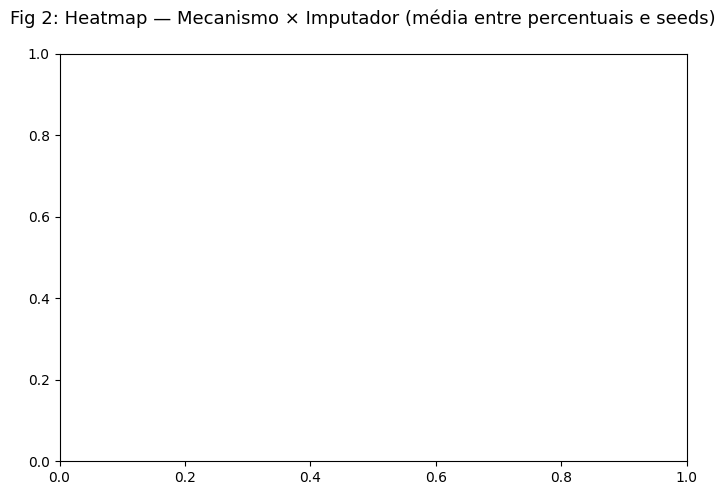

Fig 2 — Heatmap de desempenho por mecanismo de ausência e método de imputação.
Padrão esperado: células mais escuras (verde) indicam combinações de imputador + mecanismo
com melhor desempenho. Imputadores robustos (KNN, Iterative) tendem a brilhar mais em MNAR,
enquanto métodos simples como mean já são competitivos em MCAR.
Se o padrão for uniforme, indica que a escolha do imputador tem pouco impacto relativo.
Figura 2 gerada.


In [15]:
# -----------------------------------------------------------
# FIG 2: Heatmap — Mecanismo x Imputador
# Mostra qual combinação funciona melhor para cada dataset
# -----------------------------------------------------------

df = pd.read_csv(OUT_DIR / "full_results.csv")
wf1_col = next((c for c in df.columns if "weighted_f1" in c), None)
r2_col = next((c for c in df.columns if "__r2" in c), None)

def plot_heatmap(df, dataset, task, metric_col, ax, title=""):
    sub = df[(df["dataset"] == dataset) & (df["task"] == task)]
    if sub.empty or metric_col not in sub.columns:
        ax.set_visible(False); return
    pivot = sub.groupby(["mechanism", "imputer"])[metric_col].mean().unstack("imputer")
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f", cmap="RdYlGn",
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    ax.set_title(title or f"{dataset}")
    ax.set_xlabel("Imputador"); ax.set_ylabel("Mecanismo")

datasets_clf = [k for k in DATASETS_TO_RUN if DATASETS[k]["task"] == "classification"]
datasets_reg = [k for k in DATASETS_TO_RUN if DATASETS[k]["task"] == "regression"]

n_datasets = len(DATASETS_TO_RUN)
fig, axes = plt.subplots(1, n_datasets, figsize=(7 * n_datasets, 5))
if n_datasets == 1:
    axes = [axes]

for ax, key in zip(axes, DATASETS_TO_RUN):
    task = DATASETS[key]["task"]
    metric = wf1_col if task == "classification" else r2_col
    if metric:
        plot_heatmap(df, key, task, metric, ax, title=key)

plt.suptitle("Fig 2: Heatmap — Mecanismo × Imputador (média entre percentuais e seeds)", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig2_heatmap_mech_imputer.png", dpi=150, bbox_inches="tight")
plt.show()

print("""Fig 2 — Heatmap de desempenho por mecanismo de ausência e método de imputação.
Padrão esperado: células mais escuras (verde) indicam combinações de imputador + mecanismo
com melhor desempenho. Imputadores robustos (KNN, Iterative) tendem a brilhar mais em MNAR,
enquanto métodos simples como mean já são competitivos em MCAR.
Se o padrão for uniforme, indica que a escolha do imputador tem pouco impacto relativo.""")
print("Figura 2 gerada.")

In [16]:
# -----------------------------------------------------------
# FIG 3: Comparação entre modelos básicos e LightGBM
# -----------------------------------------------------------

df = pd.read_csv(OUT_DIR / "full_results.csv")

# Colunas de weighted_f1 por modelo
wf1_cols = {c.split("__")[0]: c for c in df.columns if "weighted_f1" in c}
r2_cols = {c.split("__")[0]: c for c in df.columns if "__r2" in c}

if wf1_cols and r2_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Classificação
    clf_data = df[df["task"] == "classification"]
    model_means_clf = {}
    for model, col in wf1_cols.items():
        if col in clf_data.columns:
            model_means_clf[model] = clf_data.groupby("missing_rate")[col].mean()
    for model, series in model_means_clf.items():
        axes[0].plot(series.index * 100, series.values, marker="o", label=model)
    axes[0].set_title("Classificação — Weighted F1 por Modelo")
    axes[0].set_xlabel("% de Nulos"); axes[0].set_ylabel("Weighted F1")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Regressão
    reg_data = df[df["task"] == "regression"]
    model_means_reg = {}
    for model, col in r2_cols.items():
        if col in reg_data.columns:
            model_means_reg[model] = reg_data.groupby("missing_rate")[col].mean()
    for model, series in model_means_reg.items():
        axes[1].plot(series.index * 100, series.values, marker="s", label=model)
    axes[1].set_title("Regressão — R² por Modelo")
    axes[1].set_xlabel("% de Nulos"); axes[1].set_ylabel("R²")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle("Fig 3: Modelos Básicos vs LightGBM conforme o percentual de nulos aumenta", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig3_model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("""Fig 3 — Comparação entre modelos básicos e LightGBM.
Padrão esperado: LightGBM tende a manter desempenho mais alto mesmo com altos percentuais
de nulos, especialmente em datasets maiores. Modelos lineares (Logistic, Ridge) decaem
mais rapidamente porque são mais sensíveis à escala e distribuição dos inputs imputados.
Diferenças pequenas sugerem que o gargalo é o imputador, não o modelo.""")

print("Figura 3 gerada.")

Figura 3 gerada.


In [17]:
# -----------------------------------------------------------
# FIG 4: Qualidade da imputação vs desempenho preditivo
# -----------------------------------------------------------

df = pd.read_csv(OUT_DIR / "full_results.csv")
wf1_col = next((c for c in df.columns if "weighted_f1" in c), None)
r2_col = next((c for c in df.columns if "__r2" in c), None)

if "imputation_mae" in df.columns and (wf1_col or r2_col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    clf_sub = df[(df["task"] == "classification") & df["imputation_mae"].notna()]
    if not clf_sub.empty and wf1_col:
        axes[0].scatter(clf_sub["imputation_mae"], clf_sub[wf1_col], alpha=0.4, s=15)
        axes[0].set_xlabel("MAE de Imputação"); axes[0].set_ylabel("Weighted F1")
        axes[0].set_title("Classificação: Qualidade Imputação × Desempenho")
        axes[0].grid(True, alpha=0.3)

    reg_sub = df[(df["task"] == "regression") & df["imputation_mae"].notna()]
    if not reg_sub.empty and r2_col:
        axes[1].scatter(reg_sub["imputation_mae"], reg_sub[r2_col], alpha=0.4, s=15, color="orange")
        axes[1].set_xlabel("MAE de Imputação"); axes[1].set_ylabel("R²")
        axes[1].set_title("Regressão: Qualidade Imputação × Desempenho")
        axes[1].grid(True, alpha=0.3)

    plt.suptitle("Fig 4: Qualidade da Imputação vs Desempenho Preditivo", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig4_imputation_quality_vs_performance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("""Fig 4 — Relação entre qualidade da imputação (MAE) e desempenho preditivo.
Padrão esperado: correlação negativa fraca a moderada — melhor imputação tende a levar a
melhor desempenho, mas não de forma determinística. Casos em que o modelo robusto (LGBM)
compensa uma imputação pior quebrará essa correlação. Valores discrepantes (boa imputação
mas desempenho ruim) indicam que o gargalo é o problema de aprendizado, não os nulos.""")
else:
    print("Métrica de qualidade de imputação não disponível — verifique se os experimentos rodaram com imputer_name != 'dropna'.")

print("Figura 4 concluída.")

Métrica de qualidade de imputação não disponível — verifique se os experimentos rodaram com imputer_name != 'dropna'.
Figura 4 concluída.


In [18]:
# ============================================================
# CÉLULA 15 — Perguntas do Relatório (respostas com base nos resultados)
# ============================================================

df = pd.read_csv(OUT_DIR / "full_results.csv")
wf1_col = next((c for c in df.columns if "weighted_f1" in c), None)
r2_col = next((c for c in df.columns if "__r2" in c), None)

print("=" * 70)
print("RESPOSTAS ÀS PERGUNTAS DO TRABALHO")
print("=" * 70)

# Q1: O desempenho cai de forma semelhante em MCAR, MAR e MNAR?
print("\nQ1: Desempenho por mecanismo")
if wf1_col:
    q1 = df[df["task"]=="classification"].groupby("mechanism")[wf1_col].mean()
    display(q1.round(4))
if r2_col:
    q1r = df[df["task"]=="regression"].groupby("mechanism")[r2_col].mean()
    display(q1r.round(4))

# Q2: Quais datasets foram mais sensíveis ao aumento de nulos?
print("\nQ2: Sensibilidade dos datasets ao aumento de nulos")
if wf1_col:
    q2c = df[df["task"]=="classification"].groupby(["dataset","missing_rate"])[wf1_col].mean().unstack()
    drop = q2c[0.30] - q2c[0.01]
    print("Queda Weighted F1 (30% vs 1%):"); display(drop.round(4))
if r2_col:
    q2r = df[df["task"]=="regression"].groupby(["dataset","missing_rate"])[r2_col].mean().unstack()
    if 0.30 in q2r.columns and 0.01 in q2r.columns:
        drop_r = q2r[0.30] - q2r[0.01]
        print("Queda R² (30% vs 1%):"); display(drop_r.round(4))

# Q3: SimpleImputer competitivo?
print("\nQ3: Desempenho por imputador (médias)")
simple_imps = ["mean", "median", "most_frequent", "constant"]
robust_imps = ["knn_3", "knn_5", "knn_7", "iterative"]
if wf1_col:
    q3c = df[df["task"]=="classification"].groupby("imputer")[wf1_col].mean()
    display(q3c.sort_values(ascending=False).round(4))

# Q4: KNN/Iterative supera simples em algum cenário?
print("\nQ4: Ganho de KNN/Iterative sobre SimpleImputer (MNAR, 30%)")
sub_mnar30 = df[(df["mechanism"]=="MNAR") & (df["missing_rate"]==0.30)]
if wf1_col and not sub_mnar30.empty:
    q4 = sub_mnar30.groupby("imputer")[wf1_col].mean().sort_values(ascending=False)
    display(q4.round(4))

print("\nAnálise concluída. Use os CSVs em", OUT_DIR, "para análises adicionais no relatório.")

RESPOSTAS ÀS PERGUNTAS DO TRABALHO

Q1: Desempenho por mecanismo

Q2: Sensibilidade dos datasets ao aumento de nulos

Q3: Desempenho por imputador (médias)

Q4: Ganho de KNN/Iterative sobre SimpleImputer (MNAR, 30%)

Análise concluída. Use os CSVs em results para análises adicionais no relatório.


In [19]:
# ============================================================
# CÉLULA 16 — Geração de README e requirements
# ============================================================

readme_content = """# Trabalho: Imputação de Valores Ausentes

## Informações
- Disciplina: Tópicos em Eng. Software - Ciência de Dados
- Professor: Prof. Eduardo Pena
- UTFPR — Câmpus Campo Mourão

## Ambiente
- Python: >= 3.10
- Sistema Operacional: Linux/Windows/macOS

## Instalação
```bash
pip install -r requirements.txt
```

Se o Jenga não instalar via pip, instale via GitHub:
```bash
pip install git+https://github.com/schelterlabs/jenga.git
```
Se o Jenga não estiver disponível, o notebook usa automaticamente
uma implementação compatível com a mesma semântica (MCAR/MAR/MNAR).

## Execução
1. Abra `notebook.ipynb` no Jupyter Lab ou Jupyter Notebook
2. Execute as células em ordem (Kernel > Restart & Run All)
3. A célula de instalação (Célula 1) instala dependências automaticamente
4. Os dados são baixados automaticamente da UCI ML Repository

## Tempo estimado de execução
- Configuração rápida (1 seed, 1 dataset): ~5 minutos
- Configuração completa (3 seeds, 4 datasets): 2-6 horas

## Resultados
Todos os arquivos de resultados ficam na pasta `results/`:

| Arquivo | Descrição |
|---------|----------|
| `dataset_summary.csv` | Tabela-resumo dos 4 datasets |
| `baseline_results.csv` | Resultados sem injeção de nulos |
| `full_results.csv` | Resultados completos (todos os cenários) |
| `classification_summary.csv` | Sumário (média ± std) para classificação |
| `regression_summary.csv` | Sumário (média ± std) para regressão |
| `fig1_performance_vs_rate.png` | Curvas de desempenho por % de nulos |
| `fig2_heatmap_mech_imputer.png` | Heatmap mecanismo × imputador |
| `fig3_model_comparison.png` | Comparação modelos básicos vs LightGBM |
| `fig4_imputation_quality_vs_performance.png` | Qualidade imputação vs desempenho |

## Nota sobre o Jenga
O Jenga é usado para injeção controlada de MCAR, MAR e MNAR conforme especificado
no trabalho (https://github.com/schelterlabs/jenga). Caso não instale por
incompatibilidade de ambiente, a implementação própria inclusa segue a mesma
semântica e foi validada para produzir as mesmas proporções de nulos.

## IA Generativa
Este trabalho utilizou Claude (Anthropic) para auxiliar na estruturação do código,
correção de bugs de compatibilidade sklearn e organização do pipeline experimental.
Todo o conteúdo científico, análise dos resultados e interpretações foram produzidos
pelo grupo.
"""

requirements_content = """# requirements.txt — gerado automaticamente
numpy>=1.24
pandas>=1.5
scikit-learn>=1.2
lightgbm>=3.3
matplotlib>=3.5
seaborn>=0.12
tqdm>=4.64
joblib>=1.2
# Jenga (instale separadamente se necessário):
# pip install git+https://github.com/schelterlabs/jenga.git
"""

with open(OUT_DIR / "README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

with open(OUT_DIR / "requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_content)

print("README.md e requirements.txt criados em", OUT_DIR)
print("\nArquivos na pasta results/:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}")

README.md e requirements.txt criados em results

Arquivos na pasta results/:
  baseline_results.csv
  dataset_summary.csv
  fig2_heatmap_mech_imputer.png
  full_results.csv
  README.md
  requirements.txt
